In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, MaxPooling1D
from tensorflow.keras.utils import to_categorical


In [4]:
df = pd.read_csv("/content/pakistan_air_quality_final_clean.csv")
print(df.shape)
df.head()

(21840, 26)


,timestamp,city,latitude,longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,...,pressure,date,hour,day_of_week,month,month_name,year,is_weekend,season,aqi_category
0,2025-11-06 00:00:00,Faisalabad,31.4504,73.135,23.7,22.6,598.0,15.9,5.0,58.0,...,1023.4,2025-11-06,0,Thursday,11,November,2025,0,Autumn,Moderate
1,2025-11-06 01:00:00,Faisalabad,31.4504,73.135,25.4,24.2,790.0,21.7,5.6,51.0,...,1023.4,2025-11-06,1,Thursday,11,November,2025,0,Autumn,Moderate
2,2025-11-06 02:00:00,Faisalabad,31.4504,73.135,32.2,30.7,1048.0,29.4,6.5,42.0,...,1023.4,2025-11-06,2,Thursday,11,November,2025,0,Autumn,Moderate
3,2025-11-06 03:00:00,Faisalabad,31.4504,73.135,36.2,34.8,1176.0,33.2,7.2,42.0,...,1023.4,2025-11-06,3,Thursday,11,November,2025,0,Autumn,Moderate
4,2025-11-06 04:00:00,Faisalabad,31.4504,73.135,34.7,33.3,1053.0,29.3,7.6,58.0,...,1023.4,2025-11-06,4,Thursday,11,November,2025,0,Autumn,Moderate


In [5]:
# DATA describe
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21840 entries, 0 to 21839
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         21840 non-null  object 
 1   city              21840 non-null  object 
 2   latitude          21840 non-null  float64
 3   longitude         21840 non-null  float64
 4   pm10              21840 non-null  float64
 5   pm2_5             21840 non-null  float64
 6   carbon_monoxide   21840 non-null  float64
 7   nitrogen_dioxide  21840 non-null  float64
 8   sulphur_dioxide   21840 non-null  float64
 9   ozone             21840 non-null  float64
 10  dust              21840 non-null  float64
 11  temperature       21840 non-null  float64
 12  humidity          21840 non-null  float64
 13  precipitation     21840 non-null  float64
 14  wind_speed        21840 non-null  float64
 15  wind_direction    21840 non-null  float64
 16  pressure          21840 non-null  float6

,latitude,longitude,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,temperature,humidity,precipitation,wind_speed,wind_direction,pressure,hour,month,year,is_weekend
count,21840.000000,21840.000000,21840.000000,21840.000000,21840.0000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000,21840.000000
mean,31.037740,71.538740,88.416575,82.968141,1580.8587,39.470870,19.466383,63.802106,9.858242,13.721964,64.741667,0.018022,5.339116,178.497070,1020.052885,11.500000,7.538462,2025.384615,0.285714
std,2.670825,2.583617,66.010440,65.742106,1145.6328,32.286339,11.582885,50.401229,32.531054,5.043094,20.267453,0.209813,3.919920,119.004313,3.492249,6.922345,5.097644,0.486515,0.451764
min,24.860700,66.975000,0.500000,0.500000,91.0000,0.000000,0.100000,0.000000,0.000000,-5.900000,4.000000,0.000000,0.000000,2.000000,1006.400000,0.000000,1.000000,2025.000000,0.000000
25%,30.157500,70.295200,40.500000,34.700000,741.0000,13.400000,10.600000,21.000000,1.000000,10.200000,52.000000,0.000000,2.900000,59.000000,1017.600000,5.750000,1.000000,2025.000000,0.000000
50%,31.500050,72.270900,68.500000,62.400000,1296.5000,30.400000,17.700000,55.000000,3.000000,13.300000,64.000000,0.000000,4.200000,177.000000,1020.000000,11.500000,11.000000,2025.000000,0.000000
75%,33.565100,73.135000,117.800000,112.500000,2113.2500,57.800000,26.300000,100.000000,8.000000,16.900000,81.000000,0.000000,6.600000,295.000000,1023.400000,17.250000,12.000000,2026.000000,1.000000
max,34.015100,74.522900,488.000000,486.200000,11482.0000,185.100000,75.100000,265.000000,711.000000,30.400000,100.000000,10.000000,33.400000,360.000000,1030.800000,23.000000,12.000000,2026.000000,1.000000


In [6]:
#missing values
df.isnull().sum()

,0
timestamp,0
city,0
latitude,0
longitude,0
pm10,0
pm2_5,0
carbon_monoxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0


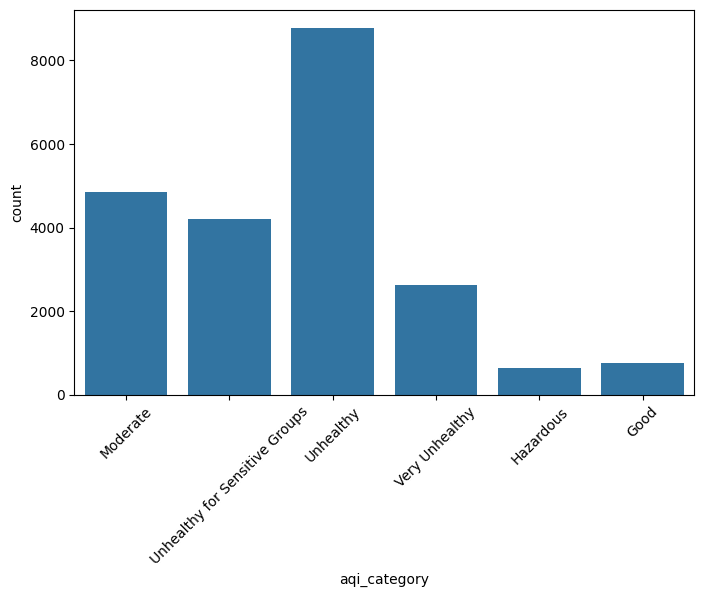

In [7]:
#class distribution
plt.figure(figsize=(8,5))
sns.countplot(x='aqi_category', data=df)
plt.xticks(rotation=45)
plt.show()

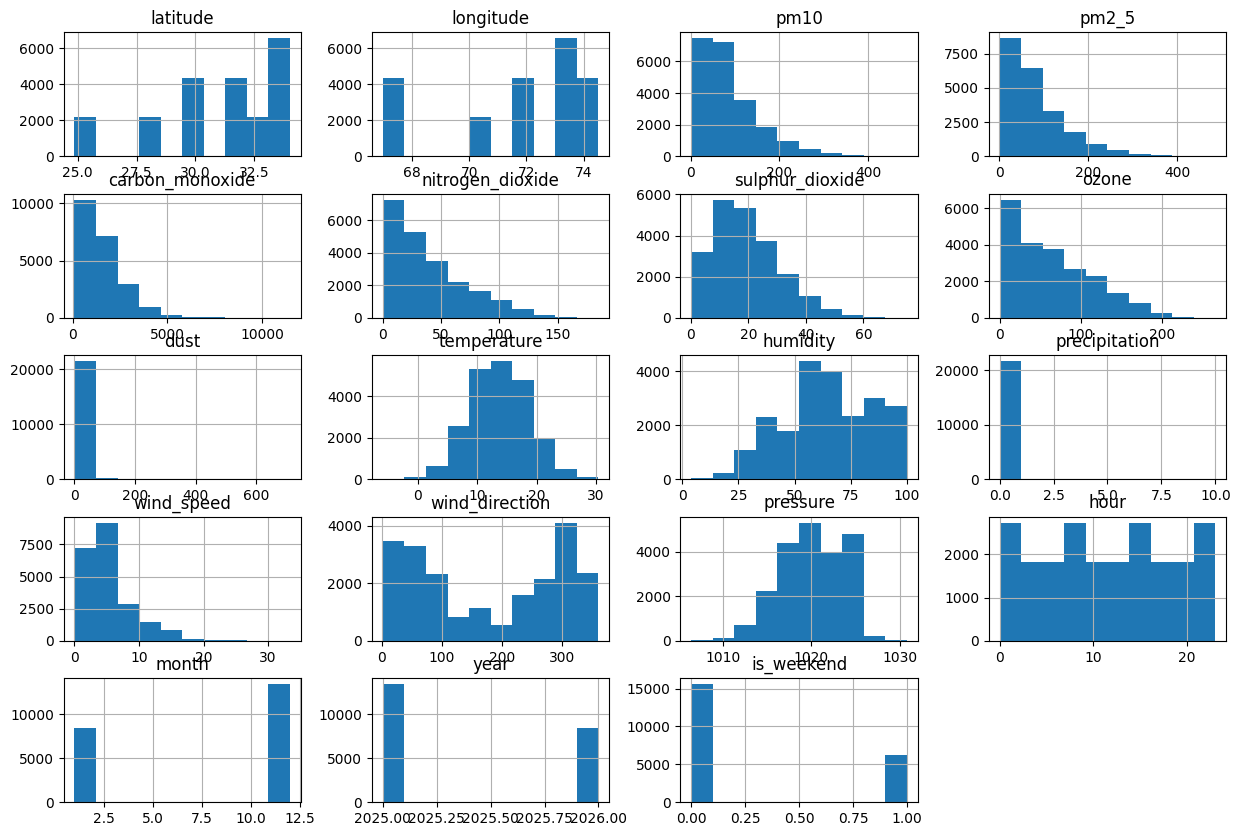

In [8]:
#Histogram
df.hist(figsize=(15,10))
plt.show()

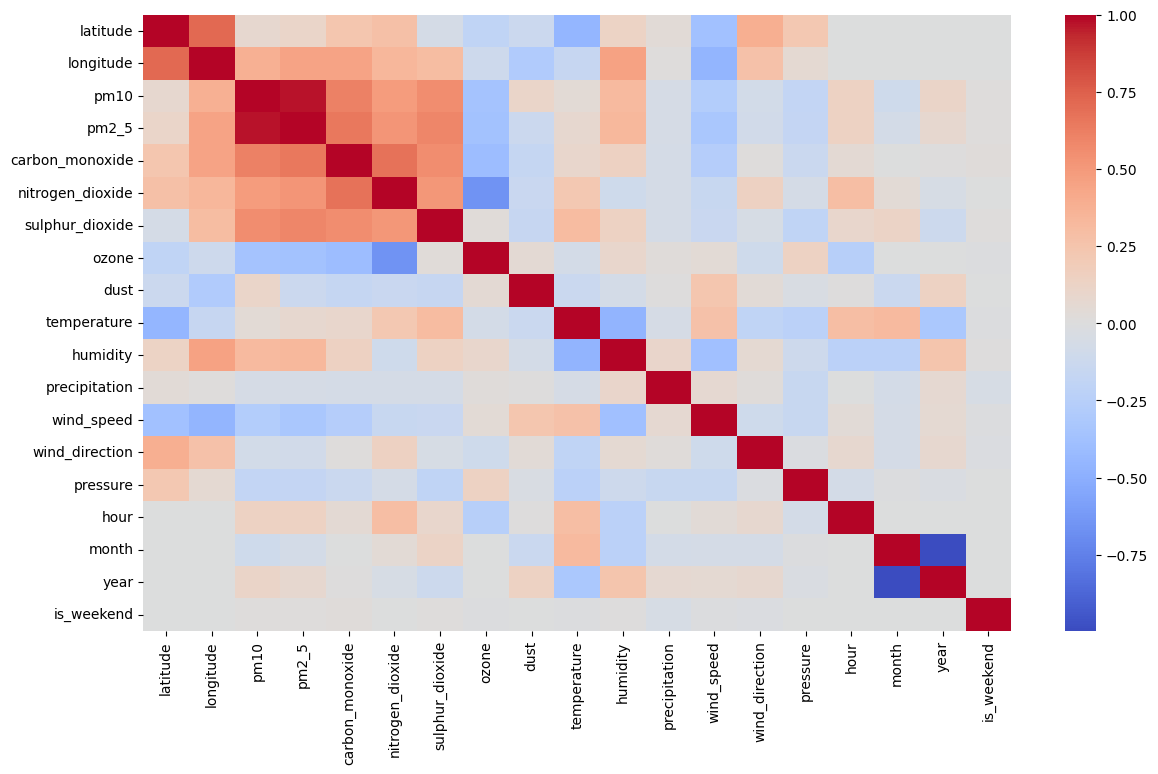

In [9]:
#relation Heatmap
plt.figure(figsize=(14,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm')
plt.show()

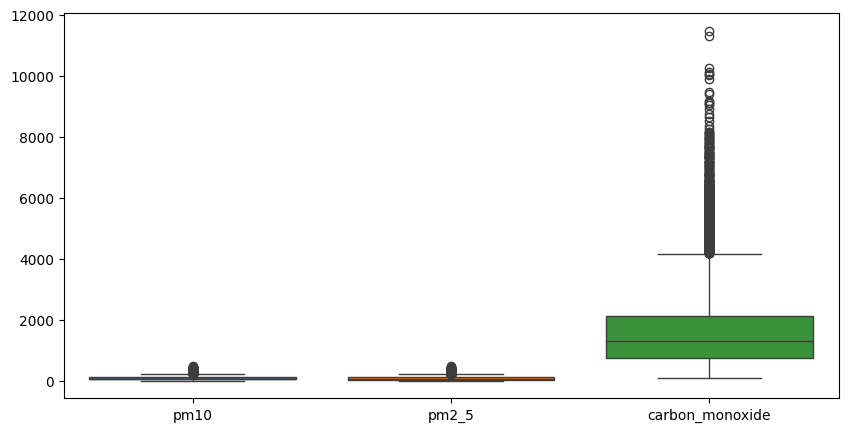

In [10]:
#boxplot
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['pm10','pm2_5','carbon_monoxide']])
plt.show()

In [45]:
# Analysis:
# PM2.5 and PM10 highly correlated with AQI
# High pollution urban cities me zyada
# Winter/autumn me pollution spike


In [11]:
# Objective 2 — Preprocessing
#remove inrelevent coloumn

df = df.drop(['timestamp','date','month_name'], axis=1)

In [13]:
#Encode Categorical Columns
encoder = LabelEncoder()

df['city'] = encoder.fit_transform(df['city'])
df['season'] = encoder.fit_transform(df['season'])
df['aqi_category'] = encoder.fit_transform(df['aqi_category'])

In [14]:
#feature and target
X = df.drop('aqi_category', axis=1)
y = df['aqi_category']

In [17]:
#Scaling
X['day_of_week'] = encoder.fit_transform(X['day_of_week'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
#Objective 3 — Data Balancing
#check imbalance data
print(y.value_counts())

aqi_category
3    8766
2    4861
4    4199
5    2617
0     759
1     638
Name: count, dtype: int64


In [19]:
#apply smote
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

In [20]:
#Check after balancing

pd.Series(y_balanced).value_counts()

,count
aqi_category,
2,8766
4,8766
3,8766
5,8766
1,8766
0,8766


In [21]:
#Objective 4 — Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

In [25]:
#Objective 5 — Train ML Models
#decision tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print(dt_pred[:10])   # first 10 predictions
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

[1 2 3 5 0 1 5 0 2 5]
Decision Tree Accuracy: 1.0


In [26]:
#randomforest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Random Forest Accuracy: 0.999809885931559


In [27]:
#3 Logistic Regression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))


Logistic Regression Accuracy: 0.978041825095057


In [29]:
#SVM
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.9666349809885931


In [32]:
#XGboot
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.9959125475285171


In [33]:
#evalution function
def evaluate(y_test, pred, name):
    print(name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred, average='weighted'))
    print("Recall:", recall_score(y_test, pred, average='weighted'))
    print("F1:", f1_score(y_test, pred, average='weighted'))
    print(classification_report(y_test, pred))

In [34]:
evaluate(y_test, dt_pred, "Decision Tree")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, lr_pred, "Logistic Regression")
evaluate(y_test, svm_pred, "SVM")
evaluate(y_test, xgb_pred, "XGBoost")

Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1731
           1       1.00      1.00      1.00      1788
           2       1.00      1.00      1.00      1754
           3       1.00      1.00      1.00      1766
           4       1.00      1.00      1.00      1673
           5       1.00      1.00      1.00      1808

    accuracy                           1.00     10520
   macro avg       1.00      1.00      1.00     10520
weighted avg       1.00      1.00      1.00     10520

Random Forest
Accuracy: 0.999809885931559
Precision: 0.9998101129334317
Recall: 0.999809885931559
F1: 0.9998098888592516
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1731
           1       1.00      1.00      1.00      1788
           2       1.00      1.00      1.00      1754
           3       1.00      1.00      1.00      1766
  

In [35]:
#Objective 6 — Feature Importance
#Random Forest se:
importance = rf.feature_importances_
features = X.columns

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_df)

             Feature  Importance
4              pm2_5    0.368168
3               pm10    0.282892
7    sulphur_dioxide    0.051441
5    carbon_monoxide    0.048803
2          longitude    0.048165
6   nitrogen_dioxide    0.044220
1           latitude    0.028680
8              ozone    0.028061
0               city    0.016598
11          humidity    0.013736
13        wind_speed    0.013596
9               dust    0.012062
15          pressure    0.010631
16              hour    0.009344
10       temperature    0.008526
14    wind_direction    0.005290
18             month    0.003238
17       day_of_week    0.002209
21            season    0.002031
19              year    0.001396
20        is_weekend    0.000515
12     precipitation    0.000398


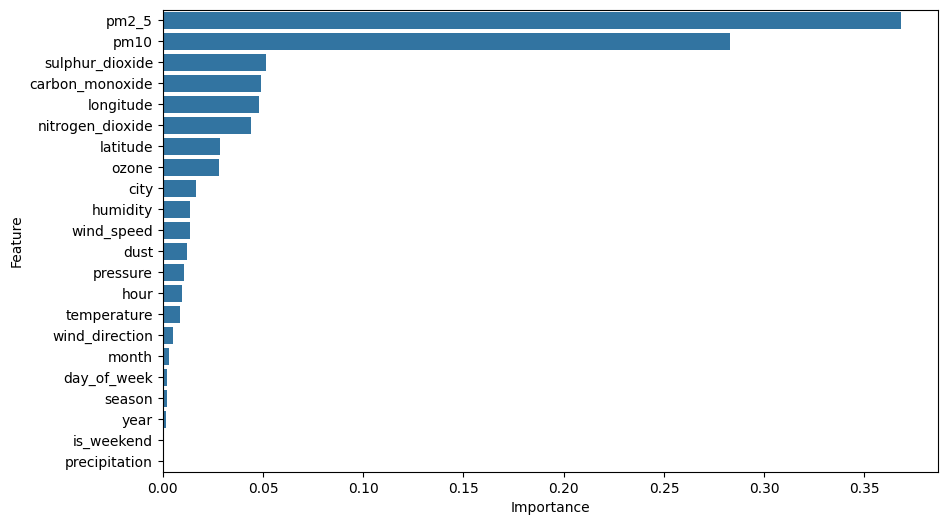

In [36]:
#plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_df)
plt.show()
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_df)
plt.show()

In [ ]:
# Expected important features:

# Particulate Matter 2.5 (PM2.5)
# Particulate Matter 10 (PM10)
# Carbon Monoxide
# Nitrogen Dioxide

In [37]:
#Objective 7 — Unseen Data Prediction
sample = X_test[:5]
pred = rf.predict(sample)
print(pred)

[1 2 3 5 0]


In [38]:
#deep learning
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [40]:
#one hot table
num_classes = len(np.unique(y_balanced))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

In [41]:
#model
model = Sequential([
    Conv1D(64, 2, activation='relu', input_shape=(X_train.shape[1],1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
#train
model.fit(
    X_train_cnn,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8617 - loss: 0.3575 - val_accuracy: 0.9355 - val_loss: 0.1817
Epoch 2/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9453 - loss: 0.1499 - val_accuracy: 0.9666 - val_loss: 0.1028
Epoch 3/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9600 - loss: 0.1058 - val_accuracy: 0.9716 - val_loss: 0.0785
Epoch 4/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9663 - loss: 0.0911 - val_accuracy: 0.9778 - val_loss: 0.0656
Epoch 5/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9702 - loss: 0.0763 - val_accuracy: 0.9783 - val_loss: 0.0628
Epoch 6/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9727 - loss: 0.0719 - val_accuracy: 0.9623 - val_loss: 0.0867
Epoch 7/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9760 - loss: 0.0649 - val_accuracy: 0.9818 - val_loss: 0.0515
Epoch 8/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9774 - loss: 0.0600 - 

In [44]:
#Evaluate:
loss, acc = model.evaluate(X_test_cnn, y_test_cat)
print("CNN Accuracy:", acc)

329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9794 - loss: 0.0516
CNN Accuracy: 0.9793726205825806
